In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
cost_per_side=0.0002
Adani=pd.read_csv("data/ADANIENT_minute.csv")
def Trade(Df,dt):
    df=Df.copy()
    df['dif']=df['close']-df['close'].shift(1)
    df['dir']=np.where(df['dif']>0,1,0)
    df.dropna(inplace=True)
    Mu2=abs(df['dif']).rolling(window=dt-1).mean().shift(1)
    Mu2.dropna(inplace=True)
    totdif=(df['dif'].rolling(window=dt-1).mean()).shift(1)*(dt-1)
    totdif.dropna(inplace=True)
    Mu1=df['dir'].rolling(window=dt-1).mean().shift(1)
    Mu1.dropna(inplace=True)
    Sigma1=df['dir'].rolling(window=dt-1).std().shift(1)
    Sigma1.dropna(inplace=True)
    moves=[]
    for x in range(0,dt+1):
        moves.append(0)
    for x in range(dt+1,len(df)-1):
        mu1=Mu1.loc[x]
        mu2=Mu2.loc[x]
        sigma1=Sigma1.loc[x]
        w=totdif[x]
        p=(2*dt*dt+(2*w*dt)/mu2+mu1/(sigma1*sigma1))/(4*dt*dt+1/(sigma1*sigma1))
        if(p>0.5):
            moves.append(1)
        else:
            moves.append(0)
    loggain=[]
    trades=0
    for x in range(dt+1,len(df)-2):
        cost=abs(moves[x]-moves[x-1])*cost_per_side
        loggain.append(moves[x]*np.log(df['close'].iloc[x]/df['close'].iloc[x-1])-cost)
    logreturns=np.log(df['close']/df['close'].shift(1))
    logreturns.dropna(inplace=True)
    marketreturn=np.exp(logreturns.sum())-1
    stratreturn=np.exp(sum(loggain))-1
    sharperatio=np.sqrt(94500)*(np.mean(loggain)/np.std(loggain))
    print("Market returns at: "+str(marketreturn))
    print("Strategy return at : "+str(stratreturn))
    print("Sharpe : "+str(sharperatio))
    print(moves)
Trade(Adani,345)

KeyboardInterrupt: 

In [ ]:
def test(Df,dt):
    df=Df.copy()
    df['dif']=df['close']-df['close'].shift(1)
    df['dir']=np.where(df['dif']>0,1,0)
    df.dropna(inplace=True)
    Mu2=abs(df['dif']).rolling(window=dt-1).mean().shift(1)
    Mu2.dropna(inplace=True)
    totdif=(df['dif'].rolling(window=dt-1).mean()).shift(1)*(dt-1)
    totdif.dropna(inplace=True)
    Mu1=df['dir'].rolling(window=dt-1).mean().shift(1)
    Mu1.dropna(inplace=True)
    Sigma1=df['dir'].rolling(window=dt-1).std().shift(1)
    Sigma1.dropna(inplace=True)
    moves=[]
    for x in range(0,dt+1):
        moves.append(0)
    for x in range(dt+1,len(df)-1):
        mu1=Mu1.loc[x]
        mu2=Mu2.loc[x]
        sigma1=Sigma1.loc[x]
        w=totdif[x]
        p=(2*dt*dt+(2*w*dt)/mu2+mu1/(sigma1*sigma1))/(4*dt*dt+1/(sigma1*sigma1))
        if(p>0.5):
            moves.append(1)
        else:
            moves.append(0)
    loggain=[]
    trades=0
    for x in range(dt+1,len(df)-2):
        cost=abs(moves[x]-moves[x-1])*cost_per_side
        loggain.append(moves[x]*np.log(df['close'].iloc[x]/df['close'].iloc[x-1])-cost)
    logreturns=np.log(df['close']/df['close'].shift(1))
    logreturns.dropna(inplace=True)
    sharperatio=np.sqrt(94500)*(np.mean(loggain)/np.std(loggain))
    return(sharperatio)
def opti(df,x1,x2,step):
    maxdt=0
    maxsharpe=0
    for x in range(x1,x2,step):
        sharpe=test(df,x)
        if sharpe>maxsharpe:
            maxsharpe=sharpe
            maxdt=x
        if x%10==0:
            print("max sharpe uptil "+str(x)+" = "+str(maxsharpe))
    print(maxdt)
    return(maxdt)

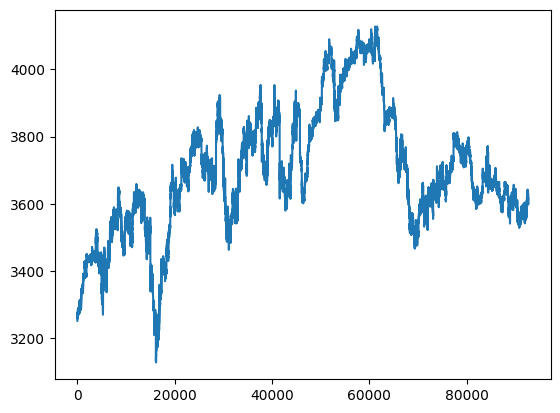

In [ ]:
Axis=pd.read_csv("data/BAJAJ-AUTO_minute.csv")
Axis.columns=Axis.columns.str.strip()
plt.plot(np.linspace(0,len(Axis),len(Axis)),Axis['close'])
plt.show()

In [ ]:
maxdt=opti(Axis,400,1000,50)
print(maxdt)
print(Trade(Axis,maxdt))

max sharpe uptil 400 = 0
max sharpe uptil 450 = 0
max sharpe uptil 500 = 0
max sharpe uptil 550 = 0
max sharpe uptil 600 = 0
max sharpe uptil 650 = 0
max sharpe uptil 700 = 0
max sharpe uptil 750 = 0
max sharpe uptil 800 = 0
max sharpe uptil 850 = 0
max sharpe uptil 900 = 0
max sharpe uptil 950 = 0
0
0


ValueError: window must be an integer 0 or greater

In [ ]:
Trade(Axis,1250)

Market returns at: 0.10935469569339729
Strategy return at : -0.2267637410675989
Sharpe : -1.3369255169969947
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,